[]

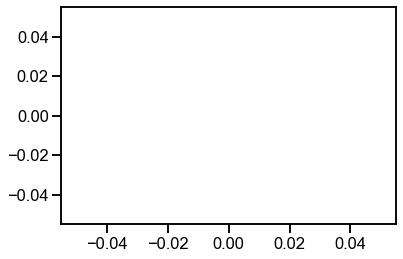

In [27]:
#!/usr/bin/env python3
"""
Date: Nov 20, 2025
Author: yying7@jh.edu

Analysis of Dataset on fixed shape and size cap with different C0 (spontaneous curvature)
Definition of spontenous curvature: center of curvature sphere above the surface is positive.

The gag file used is the same ideal 30 nm x 30 nm gag (0 eccentricity) for all the trials
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

import seaborn as sns
import os

plt.plot()
sns.set_context("talk")
plt.plot()

In [28]:
df_results = pd.read_csv("./results/results.csv")

# Reset column names
# EB: bending energy
# EA: area constraint energy
# ER: regularization energy (should converge to near 0)
# Etot: total energy
# MeanForce: mean force on every node
df_results.columns = ['FolderName', 'RelaxArea', 'c0Insertion', 'EB',\
                      'EA', 'ER', 'Etot', 'MeanForce', 'Ngags', 'Height']

# extracts the last two digits in the name,
# and save in TrialGroup and TrialNum respectively.
# e.g. _fixedmc_01, then TrialGroup is 0 and TrialNum is 1.
# Assuming df_results is already loaded

# Special note:
# the "low" trials were -0.02 ~ 0.03 nm^-1 curvature
# the "new" trials were -0.2 ~0.5 nm^-1 curvature
# the new trials have their trialgroup +10 to differentiate
df_results['TrialNum'] = df_results['FolderName'].apply(lambda x: int(x.split('_')[-1]) % 10)

df_results

,FolderName,RelaxArea,c0Insertion,EB,EA,ER,Etot,MeanForce,Ngags,Height,TrialNum
0,_c0low3_01,68000.0,-0.05,190.886,74911.000000,1025.3,76279.000,0.442413,161,28.677840,1
1,_c0low3_03,72000.0,-0.05,195.695,16734.500000,0.0,16955.500,0.154870,161,28.940593,3
2,_c0low3_04,74000.0,-0.05,212.856,3524.940000,0.0,3738.370,0.034387,161,32.091858,4
3,_c0low3_05,76000.0,-0.05,109.390,0.000090,0.0,109.399,0.000409,161,32.586538,5
4,_c0low3_06,78000.0,-0.05,112.063,0.000295,0.0,112.074,0.000651,161,33.144086,6
...,...,...,...,...,...,...,...,...,...,...,...
204,_change_ecc_spontcurv_54,74000.0,0.01,402.668,1950.380000,0.0,2353.510,0.069197,75,29.046532,4
205,_change_ecc_spontcurv_55,76000.0,0.01,335.778,0.010629,0.0,335.805,0.000905,75,28.997797,5
206,_change_ecc_spontcurv_56,78000.0,0.01,479.672,95.480300,0.0,575.587,0.010013,75,30.099584,6
207,_change_ecc_spontcurv_57,80000.0,0.01,584.976,7141.390000,0.0,7727.590,0.058619,75,30.387976,7


# Process data for no ecc

In [29]:
# Note using "low" only since "new" were too far away
df_results_no_ecc = df_results[df_results['FolderName'].apply(lambda x: (x.split('_')[1] == "c0low" or \
                                                                         x.split('_')[1] == "c0low3" or \
                                                                  x.split('_')[1] == "c0lown"))]
df_results_no_ecc['TrialGroup'] = df_results_no_ecc['FolderName'].apply(lambda x: (x.split('_')[1] == "c0lown") * 10\
                                                          + int(x.split('_')[-1]) // 10)
df_results_no_ecc['TrialGroup'] = df_results_no_ecc['FolderName'].apply(lambda x: (x.split('_')[1] == "c0low3") * 20\
                                                          + int(x.split('_')[-1]) // 10)
df_results_no_ecc = df_results_no_ecc[df_results_no_ecc['ER'] < 0.1]
df_results_no_ecc

/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_26600/3024851661.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_results_no_ecc['TrialGroup'] = df_results_no_ecc['FolderName'].apply(lambda x: (x.split('_')[1] == "c0lown") * 10\
/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_26600/3024851661.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_results_no_ecc['TrialGroup'] = df_results_no_ecc['FolderName'].apply(lambda x: (x.split('_')[1] == "c0low3") * 20\


,FolderName,RelaxArea,c0Insertion,EB,EA,ER,Etot,MeanForce,Ngags,Height,TrialNum,TrialGroup
1,_c0low3_03,72000.0,-0.05,195.6950,16734.500000,0.000000e+00,16955.5000,0.154870,161,28.940593,3,20
2,_c0low3_04,74000.0,-0.05,212.8560,3524.940000,0.000000e+00,3738.3700,0.034387,161,32.091858,4,20
3,_c0low3_05,76000.0,-0.05,109.3900,0.000090,0.000000e+00,109.3990,0.000409,161,32.586538,5,20
4,_c0low3_06,78000.0,-0.05,112.0630,0.000295,0.000000e+00,112.0740,0.000651,161,33.144086,6,20
5,_c0low3_07,80000.0,-0.05,313.5520,4952.300000,3.688290e-23,5268.1000,0.048057,161,33.465744,7,20
...,...,...,...,...,...,...,...,...,...,...,...,...
81,_c0lown_08,82000.0,-0.03,285.9210,21598.500000,0.000000e+00,22102.9000,0.424418,161,33.476003,8,0
84,_c0lown_14,74000.0,-0.04,138.0170,3510.660000,0.000000e+00,3653.1200,0.046136,161,32.077003,4,1
85,_c0lown_15,76000.0,-0.04,58.6336,0.000266,0.000000e+00,58.6360,0.000218,161,32.537077,5,1
86,_c0lown_16,78000.0,-0.04,68.1207,0.000535,0.000000e+00,68.1271,0.000481,161,33.098777,6,1


# Process data for ecc

In [30]:
# Note using "low" only since "new" were too far away
df_results_ecc = df_results[df_results['FolderName'].apply(lambda x: (x.split('_')[1] == "change"))]
df_results_ecc['TrialGroup'] = df_results_ecc['FolderName'].apply(lambda x: (x.split('_')[-2] == "spontcurv2") * 10 + int(x.split('_')[-1]) // 10)
df_results_ecc = df_results_ecc[df_results_ecc['ER'] < 0.1]
df_results_ecc = df_results_ecc.reset_index(drop=True)
df_results_ecc

/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_26600/617436039.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_results_ecc['TrialGroup'] = df_results_ecc['FolderName'].apply(lambda x: (x.split('_')[-2] == "spontcurv2") * 10 + int(x.split('_')[-1]) // 10)


,FolderName,RelaxArea,c0Insertion,EB,EA,ER,Etot,MeanForce,Ngags,Height,TrialNum,TrialGroup
0,_change_ecc_spontcurv2_05,76000.0,-0.05,96.4809,0.000137,0.000000e+00,96.4838,0.000267,75,29.843372,5,10
1,_change_ecc_spontcurv2_06,78000.0,-0.05,191.0580,45.183200,0.000000e+00,236.3580,0.007985,75,30.124768,6,10
2,_change_ecc_spontcurv2_13,72000.0,-0.06,309.0550,16682.100000,0.000000e+00,17014.1000,0.124530,75,28.929893,3,11
3,_change_ecc_spontcurv2_14,74000.0,-0.06,298.5040,2015.570000,0.000000e+00,2314.5800,0.031648,75,29.066729,4,11
4,_change_ecc_spontcurv2_15,76000.0,-0.06,173.1000,0.000028,0.000000e+00,173.1080,0.000343,75,29.834911,5,11
5,_change_ecc_spontcurv2_16,78000.0,-0.06,291.9300,58.038600,0.000000e+00,350.2290,0.020029,75,30.104085,6,11
6,_change_ecc_spontcurv2_43,72000.0,0.02,590.1900,16636.100000,0.000000e+00,17241.6000,0.188525,75,28.927396,3,14
7,_change_ecc_spontcurv2_44,74000.0,0.02,584.1280,1927.060000,0.000000e+00,2511.3900,0.035415,75,29.037600,4,14
8,_change_ecc_spontcurv2_45,76000.0,0.02,498.5170,0.015901,0.000000e+00,498.5560,0.001499,75,28.891578,5,14
9,_change_ecc_spontcurv2_46,78000.0,0.02,668.0210,75.556800,0.000000e+00,743.6730,0.013173,75,30.078242,6,14


# Plot for 0 ecc

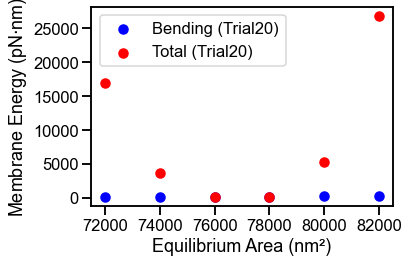

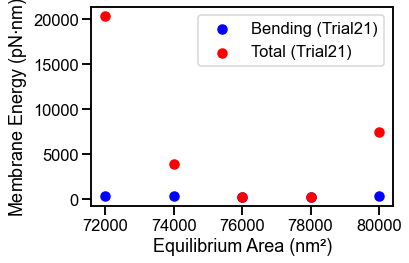

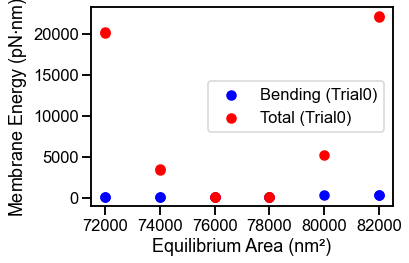

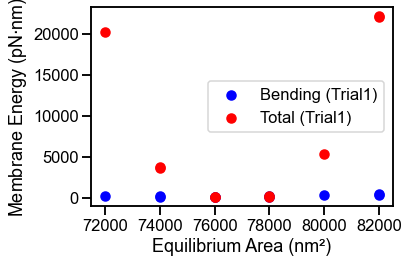

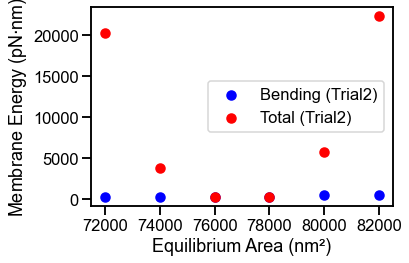

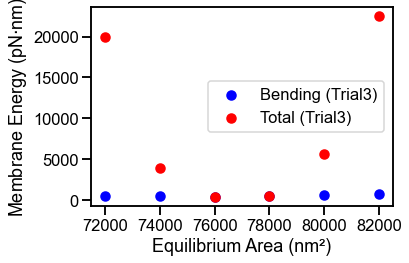

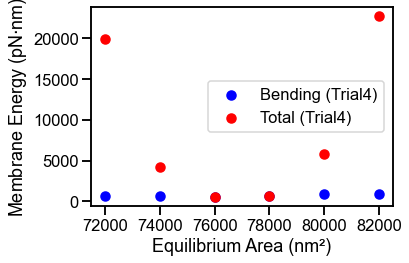

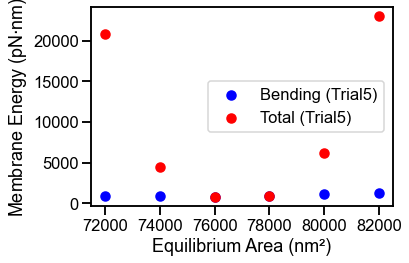

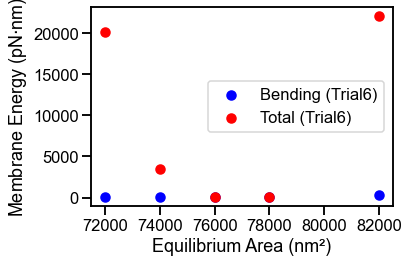

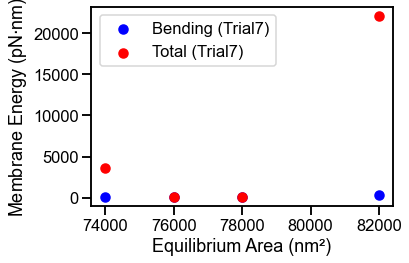

'./svg'

In [31]:
"""
For every trial group, draw a plot of EB on y-axis and RelaxArea on x-axis.
Set the axis label and tick font to Arial. Set x-axis name to Equilibrium Area (nm^2)
(the ^2 should be superscript) and y-axis name to Membrane Bending Energy (pN{dot}nm)
(the dot should be a dot product symbol). Save each plot with a distinct name as .svg
in the ./svg directory.

Repeat that process for Etot Membrane Total Energy (pN{dot}nm) versus RelaxArea
"""

# Create directory to save plots
output_dir = "./svg"
os.makedirs(output_dir, exist_ok=True)

# Unique trial groups
trial_groups = df_results_no_ecc['TrialGroup'].unique()

# Define superscript format for labels
x_label = "Equilibrium Area (nm²)"
y_label = r"Membrane Energy (pN$\cdot$nm)"

# Generate plots for each trial group
for group in trial_groups:
    df_group = df_results_no_ecc[df_results_no_ecc['TrialGroup'] == group]

    # Plot EB vs RelaxArea
    plt.figure(figsize=(6, 4))
    plt.scatter(df_group['RelaxArea'], df_group['EB'], color='b', label=f'Bending (Trial{group})')

    # Plot Etot vs RelaxArea
    plt.scatter(df_group['RelaxArea'], df_group['Etot'], color='r', label=f'Total (Trial{group})')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'TrialGroup_{group}_EB_Etot_vs_RelaxArea.svg'), format='svg')
    plt.show()

# Notify user that the plots are saved
output_dir


In [32]:
"""
(1) group by GagDistance and calculate the minimum bending energy and total energy in each group
(2) in each group, use resampling to calculate error of MINIMUM.
    See the following function docstring for more information.
    
(3) Initiate a plot with two subplots. Plot minimum bending energy on y-axis
    and Gag-Distance on x-axis with a bar plot on the first subplot.
    Use a single-sided errorbar that only goes upwards to show the error of minimum.
(4) Repeat that for total energy on the second subplot.
"""

# Function to perform resampling to estimate error of minimum energy
def resampling_min_error(data, num_samples=10000, confidence=0.90):
    """
    Perform a bootstrap resampling test to estimate the error of the minimum energy in each GagDistance group.
    
    The process involves:
    - Randomly resampling (with replacement) the energy values in the group.
    - Computing the minimum energy for each resampled dataset.
    - Calculating the upper bound error based on a one-sided confidence interval.

    Args:
    - data: The energy values of a given group.
    - num_samples: Number of bootstrap samples to generate.
    - confidence: Confidence level for the upper bound error estimation.

    Returns:
    - The upper error estimate for the minimum energy.
    """
    min_values = []
    for _ in range(num_samples):
        resampled_data = np.random.choice(data, size=len(data), replace=True)
        min_values.append(np.min(resampled_data))
    
    #print(min_values)
    # Compute the one-sided error bound at the given confidence level
    error = np.percentile(min_values, (confidence) * 100) - np.min(data)
    #print(error)
    return error

[  0.33     2.673    0.      19.1484  37.3501  53.47    69.224   96.431
 130.173  159.122 ]
[  0.335    2.675    9.4911  19.154   37.3611  53.485   69.254   96.687
 130.208  159.15  ]


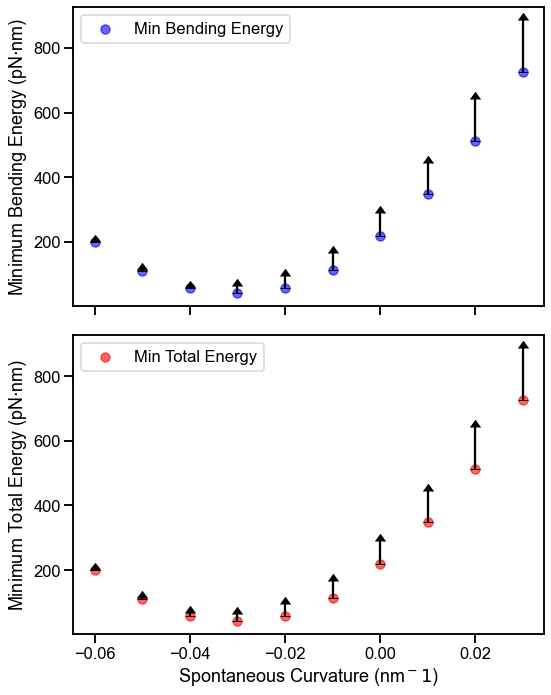

In [33]:
# Group by c0Insertion and compute the minimum values
grouped_df = df_results_no_ecc.groupby("c0Insertion").agg({"EB": "min", "Etot": "min"}).reset_index()

# Compute error estimates for minimum bending and total energy
error_eb = []
error_etot = []

for c0 in grouped_df["c0Insertion"]:
    subset_eb = df_results_no_ecc[df_results_no_ecc["c0Insertion"] == c0]["EB"]
    subset_etot = df_results_no_ecc[df_results_no_ecc["c0Insertion"] == c0]["Etot"]
    
    error_eb.append(resampling_min_error(subset_eb))
    error_etot.append(resampling_min_error(subset_etot))

# Convert errors to numpy array
error_eb = np.array(error_eb)
print(error_eb)
error_etot = np.array(error_etot)
print(error_etot)
error_eb_no_ecc = error_eb
error_etot_no_ecc = error_etot

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# First subplot - Minimum Bending Energy
axes[0].scatter(grouped_df["c0Insertion"], grouped_df["EB"], color='blue', alpha=0.6, label="Min Bending Energy")
axes[0].errorbar(grouped_df["c0Insertion"], grouped_df["EB"],
                 yerr=error_eb, fmt='none', ecolor='black', capsize=5, lolims=True)
axes[0].set_ylabel(r"Minimum Bending Energy (pN$\cdot$nm)")
axes[0].legend()

# Second subplot - Minimum Total Energy
axes[1].scatter(grouped_df["c0Insertion"], grouped_df["Etot"], color='red', alpha=0.6, label="Min Total Energy")
axes[1].errorbar(grouped_df["c0Insertion"], grouped_df["Etot"],
                 yerr=error_etot, fmt='none', ecolor='black', capsize=5, lolims=True)
axes[1].set_xlabel("Spontaneous Curvature (nm$^-1$)")
axes[1].set_ylabel(r"Minimum Total Energy (pN$\cdot$nm)")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'All_{group}_EB_Etot_vs_c0_no_exclusion_ver.svg'), format='svg')
plt.show()



Calculate Theoretical minimum

0.8 * pi * kappa = 209.607058272

Add relaxation

8pikappa * (0.75) ^ 2 * 35.4^2 / (130^2 - 35.4^2)
  = (0.75) ^ 2 * 35.4^2 / (70.8^2 - 35.4^2) * 8 * 3.1415926 * 83.4
  = 393.013426
  
  = 87.0574665997
  
  296.664524872 pNnm


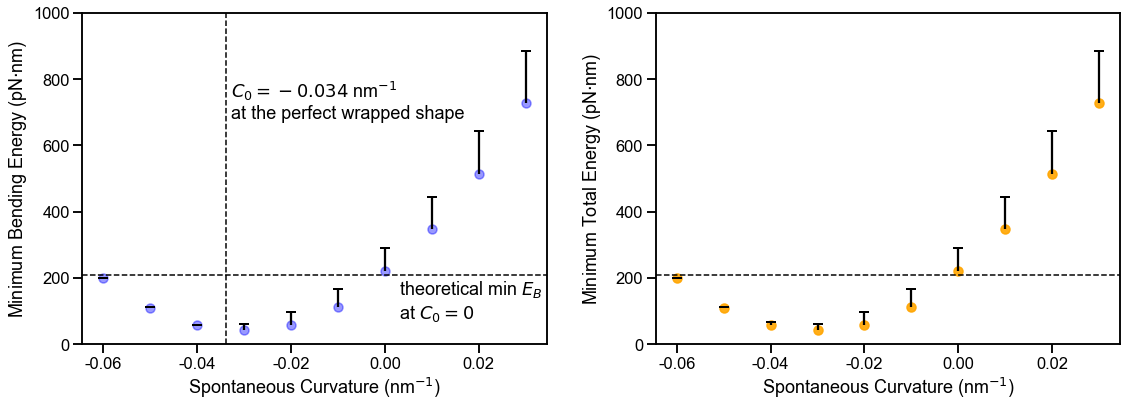

In [34]:
# Group by c0Insertion and compute the minimum values
grouped_df = df_results_no_ecc.groupby("c0Insertion").agg({"EB": "min", "Etot": "min"}).reset_index()
grouped_df["c0Insertion"] = grouped_df["c0Insertion"].astype(float)

xvals = grouped_df["c0Insertion"].values  # numeric!

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bending_energy_color = 'blue'
total_energy_color = 'orange'
horizontal_line_value = 209.607058272
vertical_line_value = -0.03389830508  # 2/59

# -------- First subplot --------
axes[0].scatter(xvals, grouped_df["EB"],
                color=bending_energy_color, alpha=0.4,
                label="Min Bending Energy")

_, cl, _ = axes[0].errorbar(xvals, grouped_df["EB"],
                            yerr=error_eb, fmt='none',
                            ecolor='black', capsize=5,
                            capthick=2, lolims=True)
cl[0].set_marker('_')
cl[1].set_marker('')

axes[0].set_xlabel("Spontaneous Curvature (nm$^{-1}$)")
axes[0].set_ylabel(r"Minimum Bending Energy (pN$\cdot$nm)")
axes[0].set_ylim(0, 1000)

axes[0].text(0.003, horizontal_line_value - 10,  # <-- use a realistic x here
             "theoretical min $E_B$\nat $C_0 = 0$",
             color='black', fontsize=18, ha='left', va='top')

axes[0].text(vertical_line_value + 0.001, 800,  # <-- use a realistic x here
             "$C_0=-0.034$ nm$^{-1}$\nat the perfect wrapped shape",
             color='black', fontsize=18, ha='left', va='top')

axes[0].axhline(y=horizontal_line_value, color='black', linestyle='--', linewidth=1.5)
axes[0].axvline(x=vertical_line_value,   color='black', linestyle='--', linewidth=1.5)

# -------- Second subplot --------
axes[1].scatter(xvals, grouped_df["Etot"],
                color=total_energy_color, alpha=0.9,
                label="Min Total Energy")

_, cl, _ = axes[1].errorbar(xvals, grouped_df["Etot"],
                            yerr=error_etot, fmt='none',
                            ecolor='black', capsize=5,
                            capthick=2, lolims=True)
cl[0].set_marker('_')
cl[1].set_marker('')

axes[1].set_xlabel("Spontaneous Curvature (nm$^{-1}$)")
axes[1].set_ylabel(r"Minimum Total Energy (pN$\cdot$nm)")
axes[1].set_ylim(0, 1000)
axes[1].axhline(y=horizontal_line_value, color='black', linestyle='--', linewidth=1.5)

# Pretty-print x-ticks to 2 decimals while keeping axis numeric
import matplotlib.ticker as mtick
for ax in axes:
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig(os.path.join(
    output_dir,
    f'All_{group}_EB_Etot_vs_Spontcurv_no_exclusion_ver_add_minebline.svg'),
    format='svg')
plt.show()


### Joint Bootstrapping

In [35]:
# Group by GagDistance and compute the minimum values
grouped_df_no_ecc = df_results_no_ecc.groupby(["TrialGroup"],\
                                group_keys=False).apply(lambda g: g.loc[g['Etot'].idxmin()])
grouped_df_no_ecc

/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_26600/3777312442.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_df_no_ecc = df_results_no_ecc.groupby(["TrialGroup"],\


,FolderName,RelaxArea,c0Insertion,EB,EA,ER,Etot,MeanForce,Ngags,Height,TrialNum,TrialGroup
TrialGroup,,,,,,,,,,,,
0,_c0lown_05,76000.0,-0.03,43.2096,0.000434,2.832530e-21,43.2113,0.000291,161,32.464066,5,0
1,_c0lown_15,76000.0,-0.04,58.6336,0.000266,0.000000e+00,58.6360,0.000218,161,32.537077,5,1
2,_c0low_25,76000.0,0.00,219.4470,0.003988,1.523570e-08,219.4550,0.001773,161,31.915449,5,2
3,_c0low_35,76000.0,0.01,347.1500,0.005361,7.201860e-11,347.1620,0.001371,161,31.680908,5,3
4,_c0low_45,76000.0,0.02,512.4660,0.007722,0.000000e+00,512.4900,0.001613,161,31.543280,5,4
5,_c0low_55,76000.0,0.03,726.4710,0.012187,0.000000e+00,726.5180,0.002460,161,31.503407,5,5
6,_c0low_65,76000.0,-0.03,43.2096,0.000434,2.832530e-21,43.2113,0.000291,161,32.464066,5,6
7,_c0low_75,76000.0,-0.04,58.6336,0.000266,0.000000e+00,58.6360,0.000218,161,32.537077,5,7
20,_c0low3_05,76000.0,-0.05,109.3900,0.000090,0.000000e+00,109.3990,0.000409,161,32.586538,5,20


In [36]:
import itertools

def resampling_joint_min_error(
    df_subset, 
    num_samples=10000, 
    confidence=0.95,
    joint_confidence=0.90
):
    data = df_subset[['Etot', 'EB', 'EA', 'Height']].to_numpy()
    n = len(data)

    # Generate indices: shape (num_samples, n)
    sample_indices = np.random.randint(0, n, size=(num_samples, n))

    # Resample all data in one go: shape (num_samples, n, 4)
    resampled = data[sample_indices]

    # Extract Etot column (index 0): shape (num_samples, n)
    etot_vals = resampled[:, :, 0]

    # Find index of min Etot for each resample
    min_indices = np.argmin(etot_vals, axis=1)  # shape (num_samples,)

    # Use advanced indexing to gather the rows where Etot is minimal
    row_indices = np.arange(num_samples)
    min_rows = resampled[row_indices, min_indices]  # shape (num_samples, 4)

    # Extract columns
    etot_mins = min_rows[:, 0]
    eb_mins = min_rows[:, 1]
    ea_mins = min_rows[:, 2]
    height_mins = min_rows[:, 3]
    ea_ratio_mins = ea_mins / etot_mins

    # Compute true minimum row from original data
    true_min_row = data[np.argmin(data[:, 0])]
    true_etot = true_min_row[0]

    # Percentile computation
    etot_error = np.percentile(etot_mins, confidence * 100) - true_etot

    alpha = (1 - joint_confidence) / 2
    q_low = 100 * alpha
    q_high = 100 * (1 - alpha)

    return {
        'Etot_err': etot_error,
        'EB_err_l': np.percentile(eb_mins, q_low),
        'EB_err_u': np.percentile(eb_mins, q_high),
        'EA_err_l': np.percentile(ea_mins, q_low),
        'EA_err_u': np.percentile(ea_mins, q_high),
        'height_err_l': np.percentile(height_mins, q_low),
        'height_err_u': np.percentile(height_mins, q_high),
        'EA_ratio_err_l': np.percentile(ea_ratio_mins, q_low),
        'EA_ratio_err_u': np.percentile(ea_ratio_mins, q_high),
    }


trial_groups = df_results_no_ecc['TrialGroup'].unique()

# Loop through trial and size groups
for trial_group in trial_groups:
    df_subset = df_results_no_ecc[(df_results_no_ecc['TrialGroup'] == trial_group)]
    errors = resampling_joint_min_error(df_subset)

    for key, value in errors.items():
        grouped_df_no_ecc.loc[
            (grouped_df_no_ecc['TrialGroup'] == trial_group), key
        ] = value


### Joint Bootstrapping result

In [37]:
grouped_df_no_ecc

,FolderName,RelaxArea,c0Insertion,EB,EA,ER,Etot,MeanForce,Ngags,Height,...,TrialGroup,Etot_err,EB_err_l,EB_err_u,EA_err_l,EA_err_u,height_err_l,height_err_u,EA_ratio_err_l,EA_ratio_err_u
TrialGroup,,,,,,,,,,,,,,,,,,,,,
0,_c0lown_05,76000.0,-0.03,43.2096,0.000434,2.832530e-21,43.2113,0.000291,161,32.464066,...,0,19.1540,43.2096,62.358,0.000434,0.001350,32.247783,33.011071,1.003580e-05,0.000022
1,_c0lown_15,76000.0,-0.04,58.6336,0.000266,0.000000e+00,58.6360,0.000218,161,32.537077,...,1,54.3510,58.6336,112.983,0.000266,0.001526,32.006825,33.098777,4.543949e-06,0.000014
2,_c0low_25,76000.0,0.00,219.4470,0.003988,1.523570e-08,219.4550,0.001773,161,31.915449,...,2,3592.6550,219.4470,303.819,0.003988,3505.140000,31.915449,32.792419,1.817393e-05,0.919475
3,_c0low_35,76000.0,0.01,347.1500,0.005361,7.201860e-11,347.1620,0.001371,161,31.680908,...,3,3517.1880,347.1500,458.863,0.005361,3404.610000,31.680908,32.909059,1.544152e-05,0.881030
4,_c0low_45,76000.0,0.02,512.4660,0.007722,0.000000e+00,512.4900,0.001613,161,31.543280,...,4,3693.2000,512.4660,667.076,0.007722,3528.650000,31.543280,32.644849,1.506722e-05,0.839018
5,_c0low_55,76000.0,0.03,726.4710,0.012187,0.000000e+00,726.5180,0.002460,161,31.503407,...,5,3672.7720,726.4710,916.239,0.012187,3482.560000,31.503407,32.782180,1.677453e-05,0.791619
6,_c0low_65,76000.0,-0.03,43.2096,0.000434,2.832530e-21,43.2113,0.000291,161,32.464066,...,6,3477.3987,43.2096,108.683,0.000434,3410.910000,32.054173,33.011071,1.003580e-05,0.968841
7,_c0low_75,76000.0,-0.04,58.6336,0.000266,0.000000e+00,58.6360,0.000218,161,32.537077,...,7,3594.4840,58.6336,138.017,0.000266,3510.660000,32.077003,33.098777,4.543949e-06,0.961003
20,_c0low3_05,76000.0,-0.05,109.3900,0.000090,0.000000e+00,109.3990,0.000409,161,32.586538,...,20,3628.9710,109.3900,212.856,0.000090,3524.940000,32.091858,33.144086,8.257589e-07,0.942908


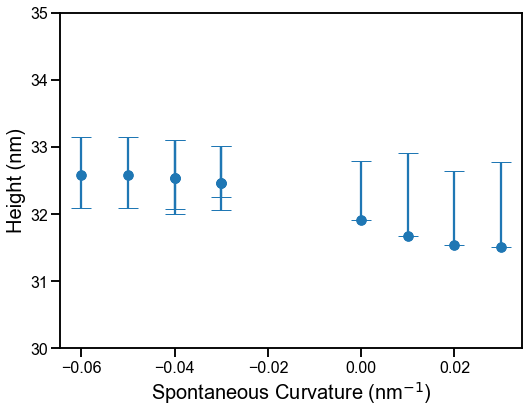

In [38]:
"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data


plt.figure(figsize=(8, 6))

# Plot each unique Ecc as a separate line
plt.scatter(grouped_df_no_ecc['c0Insertion'], grouped_df_no_ecc['Height'],
         marker='o', linestyle='-')

# Add directed error bars (only top half)
plt.errorbar(grouped_df_no_ecc['c0Insertion'], grouped_df_no_ecc['Height'],
             yerr=[grouped_df_no_ecc['Height'] - grouped_df_no_ecc['height_err_l'], grouped_df_no_ecc['height_err_u']-grouped_df_no_ecc['Height']], 
             fmt='o', capsize=10)

# Labels and title
plt.xlabel("Spontaneous Curvature (nm$^{-1}$)", fontsize=20, fontname='Arial')
plt.ylabel(r"Height (nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Height_vs_c0Insertion_by_Ecc.svg'), format='svg')
plt.ylim([30,35])

plt.show()


# Plot for ecc

[118.83    94.5771  69.1656  54.6829  47.851   52.485   56.354   66.89
  85.611  117.119 ]
[177.121  139.8742 147.7368 172.7786 179.6549 203.449  217.298  239.782
 245.117  294.442 ]


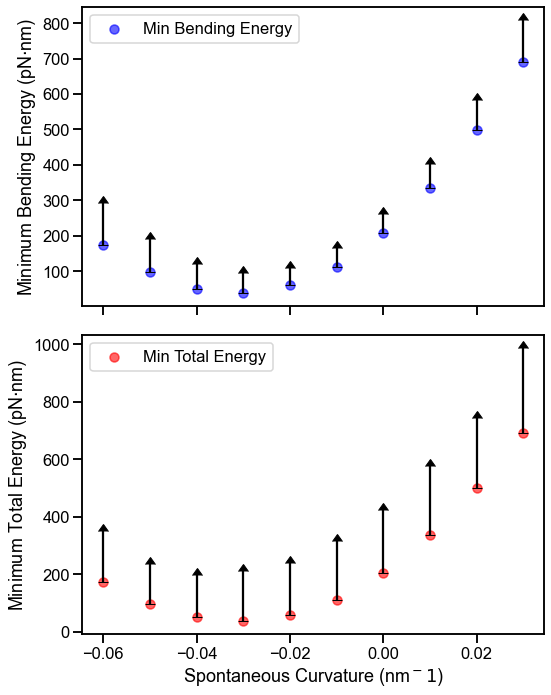

In [39]:
# Group by c0Insertion and compute the minimum values
grouped_df = df_results_ecc.groupby("c0Insertion").agg({"EB": "min", "Etot": "min"}).reset_index()

# Compute error estimates for minimum bending and total energy
error_eb = []
error_etot = []

for c0 in grouped_df["c0Insertion"]:
    subset_eb = df_results_ecc[df_results_ecc["c0Insertion"] == c0]["EB"]
    subset_etot = df_results_ecc[df_results_ecc["c0Insertion"] == c0]["Etot"]
    
    error_eb.append(resampling_min_error(subset_eb))
    error_etot.append(resampling_min_error(subset_etot))

# Convert errors to numpy array
error_eb = np.array(error_eb)
print(error_eb)
error_etot = np.array(error_etot)
print(error_etot)
error_eb_ecc = error_eb
error_etot_ecc = error_etot

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# First subplot - Minimum Bending Energy
axes[0].scatter(grouped_df["c0Insertion"], grouped_df["EB"], color='blue', alpha=0.6, label="Min Bending Energy")
axes[0].errorbar(grouped_df["c0Insertion"], grouped_df["EB"],
                 yerr=error_eb, fmt='none', ecolor='black', capsize=5, lolims=True)
axes[0].set_ylabel(r"Minimum Bending Energy (pN$\cdot$nm)")
axes[0].legend()

# Second subplot - Minimum Total Energy
axes[1].scatter(grouped_df["c0Insertion"], grouped_df["Etot"], color='red', alpha=0.6, label="Min Total Energy")
axes[1].errorbar(grouped_df["c0Insertion"], grouped_df["Etot"],
                 yerr=error_etot, fmt='none', ecolor='black', capsize=5, lolims=True)
axes[1].set_xlabel("Spontaneous Curvature (nm$^-1$)")
axes[1].set_ylabel(r"Minimum Total Energy (pN$\cdot$nm)")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'All_{group}_EB_Etot_vs_c0_no_exclusion_ver.svg'), format='svg')
plt.show()

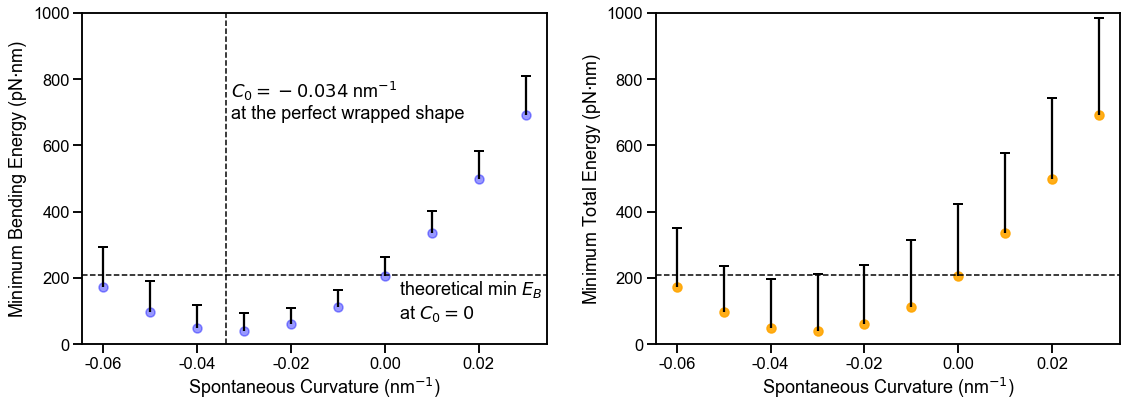

In [40]:
# Group by c0Insertion and compute the minimum values
grouped_df = df_results_ecc.groupby("c0Insertion").agg({"EB": "min", "Etot": "min"}).reset_index()
grouped_df["c0Insertion"] = grouped_df["c0Insertion"].astype(float)

xvals = grouped_df["c0Insertion"].values  # numeric!

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bending_energy_color = 'blue'
total_energy_color = 'orange'
horizontal_line_value = 209.607058272
vertical_line_value = -0.03389830508  # 2/59

# -------- First subplot --------
axes[0].scatter(xvals, grouped_df["EB"],
                color=bending_energy_color, alpha=0.4,
                label="Min Bending Energy")

_, cl, _ = axes[0].errorbar(xvals, grouped_df["EB"],
                            yerr=error_eb, fmt='none',
                            ecolor='black', capsize=5,
                            capthick=2, lolims=True)
cl[0].set_marker('_')
cl[1].set_marker('')

axes[0].set_xlabel("Spontaneous Curvature (nm$^{-1}$)")
axes[0].set_ylabel(r"Minimum Bending Energy (pN$\cdot$nm)")
axes[0].set_ylim(0, 1000)

axes[0].text(0.003, horizontal_line_value - 10,  # <-- use a realistic x here
             "theoretical min $E_B$\nat $C_0 = 0$",
             color='black', fontsize=18, ha='left', va='top')

axes[0].text(vertical_line_value + 0.001, 800,  # <-- use a realistic x here
             "$C_0=-0.034$ nm$^{-1}$\nat the perfect wrapped shape",
             color='black', fontsize=18, ha='left', va='top')

axes[0].axhline(y=horizontal_line_value, color='black', linestyle='--', linewidth=1.5)
axes[0].axvline(x=vertical_line_value,   color='black', linestyle='--', linewidth=1.5)

# -------- Second subplot --------
axes[1].scatter(xvals, grouped_df["Etot"],
                color=total_energy_color, alpha=0.9,
                label="Min Total Energy")

_, cl, _ = axes[1].errorbar(xvals, grouped_df["Etot"],
                            yerr=error_etot, fmt='none',
                            ecolor='black', capsize=5,
                            capthick=2, lolims=True)
cl[0].set_marker('_')
cl[1].set_marker('')

axes[1].set_xlabel("Spontaneous Curvature (nm$^{-1}$)")
axes[1].set_ylabel(r"Minimum Total Energy (pN$\cdot$nm)")
axes[1].set_ylim(0, 1000)
axes[1].axhline(y=horizontal_line_value, color='black', linestyle='--', linewidth=1.5)

# Pretty-print x-ticks to 2 decimals while keeping axis numeric
import matplotlib.ticker as mtick
for ax in axes:
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig(os.path.join(
    output_dir,
    f'All_{group}_EB_Etot_vs_Spontcurv_no_exclusion_ver_add_minebline.svg'),
    format='svg')
plt.show()


# Joint bootstrapping for ecc

/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_26600/682182095.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_df_ecc = df_results_ecc.groupby(["TrialGroup"],\


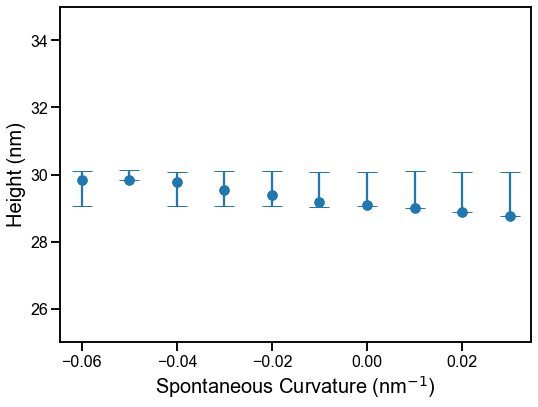

In [41]:
trial_groups = df_results_ecc['TrialGroup'].unique()

# Group by GagDistance and compute the minimum values
grouped_df_ecc = df_results_ecc.groupby(["TrialGroup"],\
                                group_keys=False).apply(lambda g: g.loc[g['Etot'].idxmin()])


# Loop through trial and size groups
for trial_group in trial_groups:
    df_subset = df_results_ecc[(df_results_ecc['TrialGroup'] == trial_group)]
    errors = resampling_joint_min_error(df_subset)

    for key, value in errors.items():
        grouped_df_ecc.loc[
            (grouped_df_ecc['TrialGroup'] == trial_group), key
        ] = value

"""
line plot of multiple line of Ngags (on x-axis) versus EB (on y-axis)
grouped by Ecc (draw one line for each unique Ecc). Draw a colorbar
for Ecc on the right hand side of the plot. 
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data


plt.figure(figsize=(8, 6))

# Plot each unique Ecc as a separate line
plt.scatter(grouped_df_ecc['c0Insertion'], grouped_df_ecc['Height'],
         marker='o', linestyle='-')

# Add directed error bars (only top half)
plt.errorbar(grouped_df_ecc['c0Insertion'], grouped_df_ecc['Height'],
             yerr=[grouped_df_ecc['Height'] - grouped_df_ecc['height_err_l'], grouped_df_ecc['height_err_u']-grouped_df_ecc['Height']], 
             fmt='o', capsize=10)

# Labels and title
plt.xlabel("Spontaneous Curvature (nm$^{-1}$)", fontsize=20, fontname='Arial')
plt.ylabel(r"Height (nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Height_vs_c0Insertion_by_Ecc.svg'), format='svg')
plt.ylim([25,35])

plt.show()


# Comparision: Height

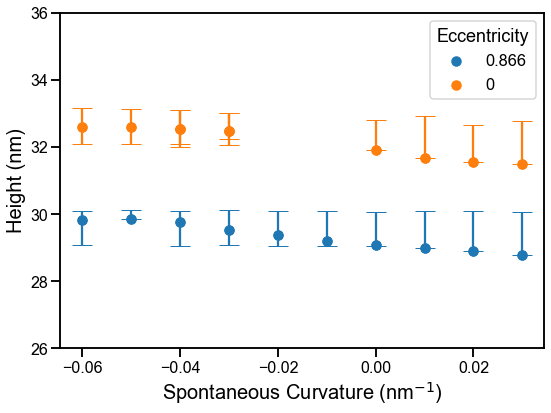

In [42]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Sample DataFrame (assuming grouped_df is already loaded)
# grouped_df = pd.read_csv("your_data.csv")  # Load your actual data


plt.figure(figsize=(8, 6))

# Plot each unique Ecc as a separate line: ecc
plt.scatter(grouped_df_ecc['c0Insertion'], grouped_df_ecc['Height'],
         marker='o', linestyle='-', label = '0.866')

# Plot each unique Ecc as a separate line: no ecc
plt.scatter(grouped_df_no_ecc['c0Insertion'], grouped_df_no_ecc['Height'],
         marker='o', linestyle='-', label = '0')

# Add directed error bars (only top half)
plt.errorbar(grouped_df_ecc['c0Insertion'], grouped_df_ecc['Height'],
             yerr=[grouped_df_ecc['Height'] - grouped_df_ecc['height_err_l'], grouped_df_ecc['height_err_u']-grouped_df_ecc['Height']], 
             fmt='o', capsize=10)

plt.errorbar(grouped_df_no_ecc['c0Insertion'], grouped_df_no_ecc['Height'],
             yerr=[grouped_df_no_ecc['Height'] - grouped_df_no_ecc['height_err_l'], grouped_df_no_ecc['height_err_u']-grouped_df_no_ecc['Height']], 
             fmt='o', capsize=10)

# Labels and title
plt.xlabel("Spontaneous Curvature (nm$^{-1}$)", fontsize=20, fontname='Arial')
plt.ylabel(r"Height (nm)", fontsize=20, fontname='Arial')
plt.xticks(fontsize=16, fontname='Arial')
plt.yticks(fontsize=16, fontname='Arial')

plt.tight_layout()
plt.savefig(os.path.join(output_dir,
                             f'Height_vs_c0Insertion_by_Ecc.svg'), format='svg')
plt.legend(title = "Eccentricity")
plt.ylim([26,36])

plt.show()


# Compare energy

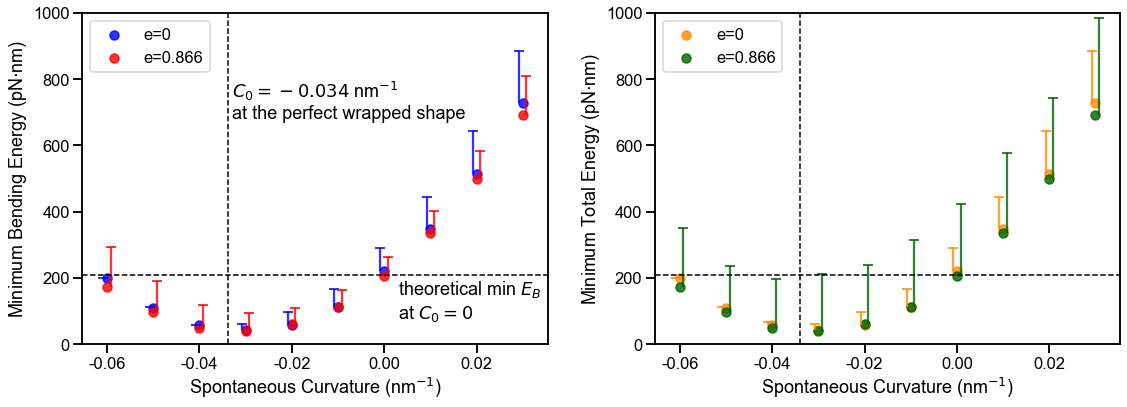

In [43]:
# Group by c0Insertion and compute the minimum values
grouped_df_energy_ecc = df_results_ecc.groupby("c0Insertion").agg({"EB": "min", "Etot": "min"}).reset_index()
grouped_df_energy_no_ecc = df_results_no_ecc.groupby("c0Insertion").agg({"EB": "min", "Etot": "min"}).reset_index()
grouped_df_energy_ecc["c0Insertion"] = grouped_df_energy_ecc["c0Insertion"].astype(float)
grouped_df_energy_no_ecc["c0Insertion"] = grouped_df_energy_no_ecc["c0Insertion"].astype(float)

xvals_ecc = grouped_df_energy_ecc["c0Insertion"].values  # numeric!
xvals_no_ecc = grouped_df_energy_no_ecc["c0Insertion"].values  # numeric!

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bending_energy_color = 'blue'
bending_energy_color_ecc = 'red'
total_energy_color = 'darkorange'
total_energy_color_ecc = 'darkgreen'
horizontal_line_value = 209.607058272
vertical_line_value = -0.03389830508  # 2/59

# -------- First subplot --------
# no ecc
axes[0].scatter(xvals_no_ecc, grouped_df_energy_no_ecc["EB"],
                color=bending_energy_color, alpha=0.8,
                label="e=0")

_, cl, _ = axes[0].errorbar(xvals_no_ecc - 0.0008, grouped_df_energy_no_ecc["EB"],
                            yerr=error_eb_no_ecc, fmt='none',
                            ecolor=bending_energy_color, capsize=5,
                            capthick=2, lolims=True, alpha=0.8)

cl[0].set_marker('_')
cl[1].set_marker('')

# ecc
axes[0].scatter(xvals_ecc, grouped_df_energy_ecc["EB"],
                color=bending_energy_color_ecc, alpha=0.8,
                label="e=0.866")

_, cl, _ = axes[0].errorbar(xvals_ecc + 0.0008, grouped_df_energy_ecc["EB"],
                            yerr=error_eb_ecc, fmt='none',
                            ecolor=bending_energy_color_ecc, capsize=5,
                            capthick=2, lolims=True, alpha=0.8)

cl[0].set_marker('_')
cl[1].set_marker('')

axes[0].set_xlabel("Spontaneous Curvature (nm$^{-1}$)")
axes[0].set_ylabel(r"Minimum Bending Energy (pN$\cdot$nm)")
axes[0].set_ylim(0, 1000)

axes[0].text(0.003, horizontal_line_value - 10,  # <-- use a realistic x here
             "theoretical min $E_B$\nat $C_0 = 0$",
             color='black', fontsize=18, ha='left', va='top')

axes[0].text(vertical_line_value + 0.001, 800,  # <-- use a realistic x here
             "$C_0=-0.034$ nm$^{-1}$\nat the perfect wrapped shape",
             color='black', fontsize=18, ha='left', va='top')

axes[0].axhline(y=horizontal_line_value, color='black', linestyle='--', linewidth=1.5)
axes[0].axvline(x=vertical_line_value,   color='black', linestyle='--', linewidth=1.5)
axes[0].legend()

# -------- Second subplot --------
# no ecc
# no ecc
axes[1].scatter(xvals_no_ecc, grouped_df_energy_no_ecc["Etot"],
                color=total_energy_color, alpha=0.8,
                label="e=0")

_, cl, _ = axes[1].errorbar(xvals_no_ecc - 0.0008, grouped_df_energy_no_ecc["Etot"],
                            yerr=error_etot_no_ecc, fmt='none',
                            ecolor=total_energy_color, capsize=5,
                            capthick=2, lolims=True, alpha=0.8)

cl[0].set_marker('_')
cl[1].set_marker('')

# ecc
axes[1].scatter(xvals_ecc, grouped_df_energy_ecc["Etot"],
                color=total_energy_color_ecc, alpha=0.8,
                label="e=0.866")

_, cl, _ = axes[1].errorbar(xvals_ecc + 0.0008, grouped_df_energy_ecc["Etot"],
                            yerr=error_etot_ecc, fmt='none',
                            ecolor=total_energy_color_ecc, capsize=5,
                            capthick=2, lolims=True, alpha=0.8)


cl[0].set_marker('_')
cl[1].set_marker('')

axes[1].set_xlabel("Spontaneous Curvature (nm$^{-1}$)")
axes[1].set_ylabel(r"Minimum Total Energy (pN$\cdot$nm)")
axes[1].set_ylim(0, 1000)
axes[1].axhline(y=horizontal_line_value, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(x=vertical_line_value,   color='black', linestyle='--', linewidth=1.5)
axes[1].legend()


# Pretty-print x-ticks to 2 decimals while keeping axis numeric
import matplotlib.ticker as mtick
for ax in axes:
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig(os.path.join(
    output_dir,
    f'All_{group}_EB_Etot_vs_Spontcurv_no_exclusion_ver_add_minebline.svg'),
    format='svg')
plt.show()


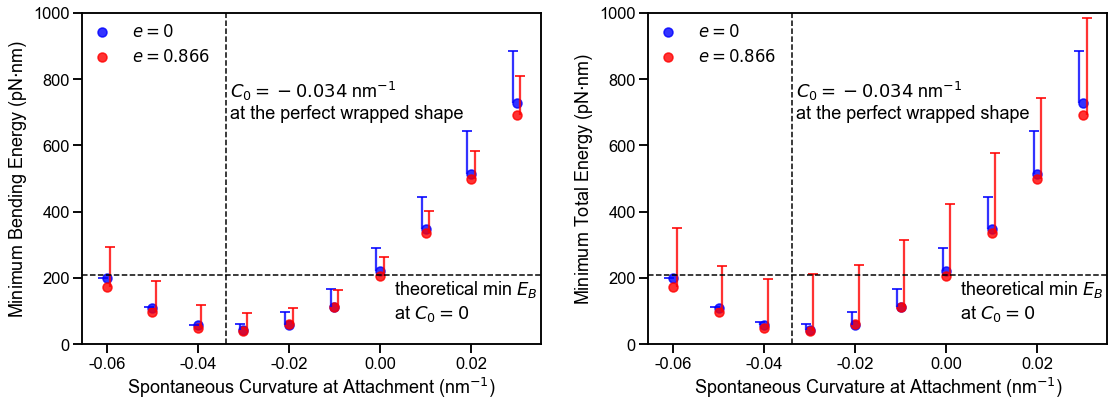

In [44]:
# Group by c0Insertion and compute the minimum values
grouped_df_energy_ecc = df_results_ecc.groupby("c0Insertion").agg({"EB": "min", "Etot": "min"}).reset_index()
grouped_df_energy_no_ecc = df_results_no_ecc.groupby("c0Insertion").agg({"EB": "min", "Etot": "min"}).reset_index()
grouped_df_energy_ecc["c0Insertion"] = grouped_df_energy_ecc["c0Insertion"].astype(float)
grouped_df_energy_no_ecc["c0Insertion"] = grouped_df_energy_no_ecc["c0Insertion"].astype(float)

xvals_ecc = grouped_df_energy_ecc["c0Insertion"].values  # numeric!
xvals_no_ecc = grouped_df_energy_no_ecc["c0Insertion"].values  # numeric!

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bending_energy_color = 'blue'
bending_energy_color_ecc = 'red'
total_energy_color = 'blue'
total_energy_color_ecc = 'red'
horizontal_line_value = 209.607058272
vertical_line_value = -0.03389830508  # 2/59

# -------- First subplot --------
# no ecc
axes[0].scatter(xvals_no_ecc, grouped_df_energy_no_ecc["EB"],
                color=bending_energy_color, alpha=0.8,
                label="$e=0$")

_, cl, _ = axes[0].errorbar(xvals_no_ecc - 0.0008, grouped_df_energy_no_ecc["EB"],
                            yerr=error_eb_no_ecc, fmt='none',
                            ecolor=bending_energy_color, capsize=5,
                            capthick=2, lolims=True, alpha=0.8)

cl[0].set_marker('_')
cl[1].set_marker('')

# ecc
axes[0].scatter(xvals_ecc, grouped_df_energy_ecc["EB"],
                color=bending_energy_color_ecc, alpha=0.8,
                label="$e=0.866$")

_, cl, _ = axes[0].errorbar(xvals_ecc + 0.0008, grouped_df_energy_ecc["EB"],
                            yerr=error_eb_ecc, fmt='none',
                            ecolor=bending_energy_color_ecc, capsize=5,
                            capthick=2, lolims=True, alpha=0.8)

cl[0].set_marker('_')
cl[1].set_marker('')

axes[0].set_xlabel("Spontaneous Curvature at Attachment (nm$^{-1}$)")
axes[0].set_ylabel(r"Minimum Bending Energy (pN$\cdot$nm)")
axes[0].set_ylim(0, 1000)

axes[0].text(0.003, horizontal_line_value - 10,  # <-- use a realistic x here
             "theoretical min $E_B$\nat $C_0 = 0$",
             color='black', fontsize=18, ha='left', va='top')

axes[0].text(vertical_line_value + 0.001, 800,  # <-- use a realistic x here
             "$C_0=-0.034$ nm$^{-1}$\nat the perfect wrapped shape",
             color='black', fontsize=18, ha='left', va='top')

axes[0].axhline(y=horizontal_line_value, color='black', linestyle='--', linewidth=1.5)
axes[0].axvline(x=vertical_line_value,   color='black', linestyle='--', linewidth=1.5)
axes[0].legend(frameon = False, loc = "upper left", bbox_to_anchor=(-0.025, 1.015))

# -------- Second subplot --------
# no ecc
# no ecc
axes[1].scatter(xvals_no_ecc, grouped_df_energy_no_ecc["Etot"],
                color=total_energy_color, alpha=0.8,
                label="$e=0$")

_, cl, _ = axes[1].errorbar(xvals_no_ecc - 0.0008, grouped_df_energy_no_ecc["Etot"],
                            yerr=error_etot_no_ecc, fmt='none',
                            ecolor=total_energy_color, capsize=5,
                            capthick=2, lolims=True, alpha=0.8)

cl[0].set_marker('_')
cl[1].set_marker('')

# ecc
axes[1].scatter(xvals_ecc, grouped_df_energy_ecc["Etot"],
                color=total_energy_color_ecc, alpha=0.8,
                label="$e=0.866$")

_, cl, _ = axes[1].errorbar(xvals_ecc + 0.0008, grouped_df_energy_ecc["Etot"],
                            yerr=error_etot_ecc, fmt='none',
                            ecolor=total_energy_color_ecc, capsize=5,
                            capthick=2, lolims=True, alpha=0.8)


cl[0].set_marker('_')
cl[1].set_marker('')

axes[1].set_xlabel("Spontaneous Curvature at Attachment (nm$^{-1}$)")
axes[1].set_ylabel(r"Minimum Total Energy (pN$\cdot$nm)")
axes[1].set_ylim(0, 1000)

axes[1].text(0.003, horizontal_line_value - 10,  # <-- use a realistic x here
             "theoretical min $E_B$\nat $C_0 = 0$",
             color='black', fontsize=18, ha='left', va='top')

axes[1].text(vertical_line_value + 0.001, 800,  # <-- use a realistic x here
             "$C_0=-0.034$ nm$^{-1}$\nat the perfect wrapped shape",
             color='black', fontsize=18, ha='left', va='top')

axes[1].axhline(y=horizontal_line_value, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(x=vertical_line_value,   color='black', linestyle='--', linewidth=1.5)
axes[1].legend(frameon = False, loc = "upper left", bbox_to_anchor=(-0.025, 1.015))


# Pretty-print x-ticks to 2 decimals while keeping axis numeric
import matplotlib.ticker as mtick
for ax in axes:
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig(os.path.join(
    output_dir,
    f'All_{group}_EB_Etot_vs_SpontCurv_same_color.svg'),
    format='svg')
plt.show()
